# WoFS tutorial: fetch → interpolate → identify → track → match

This notebook is a complete, reproducible record of every data-processing step in `python_obj`'s object-based thunderstorm verification pipeline, applied to the real example WoFS (Warn-on-Forecast System) case bundled with this repo (`test_wofs/`, 25 files, 5-min cadence, 18 ensemble members stacked inside each file).

Every step below calls the same `run_one_case(config_path)` function a standalone driver script (`python_obj/drivers/`) would call from the command line -- nothing here is a notebook-only reimplementation. Running this notebook top to bottom reproduces the entire pipeline from a real AWS fetch through to matching:

1. **Fetch** matching MRMS observations from the public `noaa-mrms-pds` AWS archive for each WoFS file's valid time.
2. **Interpolate** those raw MRMS files onto the WoFS grid.
3. **Identify objects in WoFS** -- no tracking, each of the 18 members identified separately.
4. **Identify + track objects in MRMS** (the truth series).
5. **Match** WoFS objects against MRMS objects via the Total Interest score.

All parameters live in one YAML config file, `python_obj/configs/config_sample_wofs.yaml` (a "sample config" -- one of two paired with these tutorial notebooks, see also `config_sample_mpas.yaml`), split into independently-optional sections (`fetch_mrms`, `interpolation`, `observations`, `model`, `matching`, `linear_classification`). To adapt this notebook to a different model or case, copy it and point `CONFIG_PATH` (below) at a different config file -- no other code changes needed.

See also `mpas_tutorial.ipynb`, the complementary notebook for a single-member MPAS forecast where the interpolated MRMS observations are already available on disk (no fetch/interpolate steps needed).

In [1]:
import os
import sys
from collections import Counter

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from python_obj.config import load_config
from python_obj.drivers import fetch_mrms, interpolate_mrms, identify_track_model, identify_track_mrms, run_matching
from python_obj.obj_core import read_object_file, read_match_file, iter_object_slices

CONFIG_PATH = "../configs/config_sample_wofs.yaml"

cfg = load_config(CONFIG_PATH)
for section_name in ("fetch_mrms", "interpolation", "observations", "model", "matching", "linear_classification"):
    print(f"{section_name}:\n  {getattr(cfg, section_name)}\n")

fetch_mrms:
  FetchMrmsConfig(model_input_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/wofs_case/wofs', output_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/fetched_mrms_wofs', file_pattern='*.nc', valid_time_attr='valid_time', valid_time_format='%Y%m%d_%H%M%S', init_attr=None, lead_attr=None, lead_units='hours', init_format=None, tolerance_minutes=2.5, s3_bucket='noaa-mrms-pds', mrms_product='MergedReflectivityQCComposite_00.50', mirror_subdirs=True, skip_existing=True, max_files=None)

interpolation:
  InterpolationConfig(raw_mrms_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/fetched_mrms_wofs', interp_mrms_dir='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/interp_mrms_wofs', target_grid_file='/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/wofs_case/wofs/wofs_ALL_00_20260518_2300_2300.nc', tar

## Step 1 — Fetch matching MRMS observations from AWS

`test_wofs/` has no local MRMS observations to compare against. `noaa-mrms-pds` is a public S3 bucket (no AWS credentials or SDK needed, just plain HTTPS) holding the full MRMS archive. For each WoFS file, this step derives its `valid_time` (from the `valid_time` global attribute, a ready-made `"YYYYMMDD_HHMMSS"` string in this case), lists that day's MRMS files (one HTTPS request per distinct calendar day -- cached, since the WoFS case spans a midnight crossing so only 2 unique days are ever listed), finds the nearest available MRMS timestamp within a tolerance, and downloads it.

In [2]:
fetch_summary = fetch_mrms.run_one_case(CONFIG_PATH)
print(fetch_summary)

Found 3 model files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/wofs_case/wofs'
Listing MRMS archive for 20260518 ...


FetchSummary: 3 total -- 3 downloaded
FetchSummary: 3 total -- 3 downloaded


## Step 2 — Interpolate onto the WoFS grid

MRMS is delivered on its own native grid; the fetched files above must be conservatively regridded onto WoFS's own `xlat`/`xlon` grid before objects can be compared directly. This uses `xesmf`'s conservative-remapping method, with regridding weights cached to disk (`interpolation.weight_cache_dir`) so repeat runs against the same grid pair are fast.

In [3]:
interp_summary = interpolate_mrms.run_one_case(CONFIG_PATH)
print(f"Interpolated {interp_summary.n_success}/{interp_summary.n_total} files ({interp_summary.n_failed} failed)")
if interp_summary.failures:
    for fail in interp_summary.failures:
        print(f"  FAILED: {fail.input_path}: {fail.error}")

Interpolating MRMS files from '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/fetched_mrms_wofs' -> '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/interp_mrms_wofs'
Target grid: '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/wofs_case/wofs/wofs_ALL_00_20260518_2300_2300.nc' (lat='xlat', lon='xlon')


BatchSummary: 3/3 succeeded, 0 failed
Interpolated 3/3 files (0 failed)


## Step 3 — Object identification on WoFS (no tracking, per-member)

Each WoFS file stores all 18 ensemble members stacked as a real array dimension (`comp_dz(ne=18, lat, lon)`), not one file per member (`model.stacked_members: true`). Objects are identified **separately in each member** -- no member's storms are ever mixed with another's during identification. Per the requested workflow, WoFS objects are not tracked in time (`model.track: false`); only MRMS (Step 4) is.

In [4]:
wofs_object_paths = identify_track_model.run_one_case(CONFIG_PATH)
print(f"Wrote {len(wofs_object_paths)} WoFS object files")

member_counts = Counter()
linear_counts = Counter()
total_wofs_objects = 0
for path in wofs_object_paths:
    contents = read_object_file(path)
    for member_id, valid_time, labels2d, objects in iter_object_slices(contents):
        member_counts[member_id] += len(objects)
        total_wofs_objects += len(objects)
        for obj in objects:
            linear_counts[obj.is_linear] += 1

print(f"\nTotal WoFS objects across all files/members: {total_wofs_objects}")
print("Objects per member (confirms real, non-uniform per-member identification):")
for member_id in sorted(member_counts):
    print(f"  {member_id}: {member_counts[member_id]}")

label_names = {0: "cellular", 1: "mixed", 2: "linear"}
print("\nis_linear distribution (0=cellular, 1=mixed, 2=linear):")
for code in (0, 1, 2):
    print(f"  {label_names[code]}: {linear_counts.get(code, 0)}")

Found 54 manifest entries under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/sample_data/wofs_case/wofs' (member_subdirs=False, stacked_members=True)
Identifying objects: boundary_threshold=45.0, max_value_threshold=50.2, area_threshold_km2=108.0, track=False, file_grouping=ensemble_snapshot


Wrote 3 WoFS object files



Total WoFS objects across all files/members: 1725
Objects per member (confirms real, non-uniform per-member identification):
  mem00: 80
  mem01: 100
  mem02: 84
  mem03: 111
  mem04: 101
  mem05: 97
  mem06: 108
  mem07: 106
  mem08: 97
  mem09: 87
  mem10: 90
  mem11: 98
  mem12: 95
  mem13: 82
  mem14: 96
  mem15: 86
  mem16: 102
  mem17: 105

is_linear distribution (0=cellular, 1=mixed, 2=linear):
  cellular: 1553
  mixed: 133
  linear: 39


## Step 4 — Object identification + tracking on MRMS (truth)

The interpolated MRMS series (Step 2's output) is the truth series against which WoFS is verified. Unlike WoFS, MRMS objects **are** tracked in time (`observations.track: true`) so each object carries a persistent `track_id` and an `age_seconds` since it first appeared.

In [5]:
mrms_object_paths = identify_track_mrms.run_one_case(CONFIG_PATH)
print(f"Wrote {len(mrms_object_paths)} MRMS object files")

ages = []
total_mrms_objects = 0
for path in mrms_object_paths:
    contents = read_object_file(path)
    total_mrms_objects += len(contents.objects)
    ages.extend(obj.age_seconds for obj in contents.objects if obj.age_seconds is not None)

print(f"\nTotal MRMS objects: {total_mrms_objects}")
n_new = sum(1 for a in ages if a == 0.0)
n_continuing = sum(1 for a in ages if a > 0.0)
print(f"Objects with age_seconds == 0 (newly formed): {n_new}")
print(f"Objects with age_seconds > 0 (tracked from an earlier time): {n_continuing}")
if ages:
    print(f"Max age observed: {max(ages):.0f} s ({max(ages) / 60:.1f} min)")

Found 3 interpolated MRMS files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/interp_mrms_wofs'
Identifying objects: boundary_threshold=40.0, max_value_threshold=45.0, area_threshold_km2=108.0, track=True, file_grouping=single
Wrote 3 MRMS object files



Total MRMS objects: 58
Objects with age_seconds == 0 (newly formed): 20
Objects with age_seconds > 0 (tracked from an earlier time): 38
Max age observed: 601 s (10.0 min)


## Step 5 — Matching

Every WoFS forecast (member, time) slice is matched against the nearest-in-time MRMS truth slice (within `matching.max_time_offset_minutes`) via a single global greedy Total Interest (TI) assignment: the full pairwise TI matrix is computed once, candidate pairs exceeding `matching.ti_threshold` are weighted by area ratio, sorted descending, and confirmed one at a time whenever both objects are still free. Every object ends up in exactly one of five categories: `hit`, `miss`, `false_alarm`, `truth_extra`, or `forecast_extra`.

In [6]:
matching_summary = run_matching.run_one_case(CONFIG_PATH)
print(f"Wrote {len(matching_summary.output_paths)} match files")
print(f"Skipped forecast times (no truth within tolerance): {len(matching_summary.skipped_forecast_times)}")

category_counts = Counter()
per_time_counts = {}
for path in matching_summary.output_paths:
    contents = read_match_file(path)
    vt = contents.valid_times[0]
    per_time_counts.setdefault(vt, Counter())
    for rec in contents.records:
        category_counts[rec.category] += 1
        per_time_counts[vt][rec.category] += 1

print("\nMatch category totals across all members/times:")
for category in ("hit", "miss", "false_alarm", "truth_extra", "forecast_extra"):
    print(f"  {category}: {category_counts.get(category, 0)}")

Found 3 truth files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/obj_mrms_wofs'
Found 3 forecast files under '/Users/asdf/Documents/work/2026_analysis/2026_ncar_verif/python_obj/configs/output/obj_wofs'
Matching: max_boundary_disp_km=40.0, max_centroid_disp_km=40.0, ti_threshold=0.2, max_time_offset_minutes=5.0


Wrote 3 match files
Skipped forecast times (no truth within tolerance): 0



Match category totals across all members/times:
  hit: 707
  miss: 163
  false_alarm: 675
  truth_extra: 174
  forecast_extra: 343


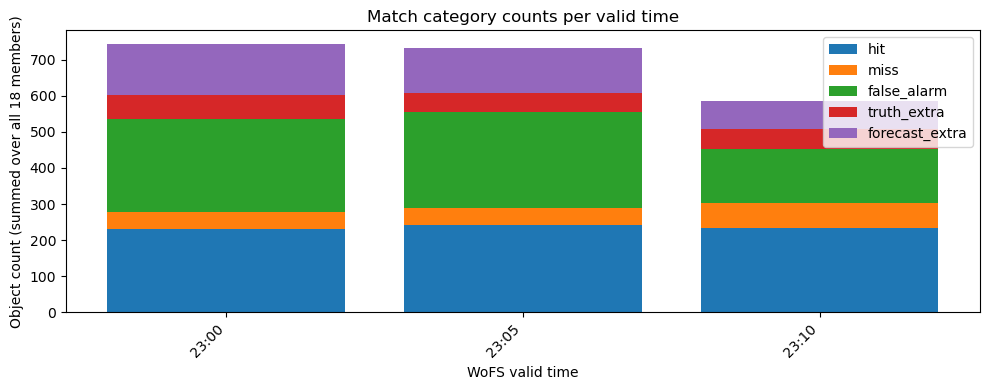

In [7]:
import matplotlib.pyplot as plt

times = sorted(per_time_counts)
categories = ("hit", "miss", "false_alarm", "truth_extra", "forecast_extra")

fig, ax = plt.subplots(figsize=(10, 4))
bottom = [0] * len(times)
for category in categories:
    values = [per_time_counts[t].get(category, 0) for t in times]
    ax.bar([t.strftime("%H:%M") for t in times], values, bottom=bottom, label=category)
    bottom = [b + v for b, v in zip(bottom, values)]
ax.set_xlabel("WoFS valid time")
ax.set_ylabel("Object count (summed over all 18 members)")
ax.set_title("Match category counts per valid time")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Closing

This notebook walked through the full pipeline for one real WoFS case. `mpas_tutorial.ipynb` is the complementary sample notebook -- a single-member MPAS forecast (`test_mpas/mem1/`, f000-f012) matched against already-interpolated MRMS, so it skips straight to object ID + matching (no fetch/interpolate steps).

Other example configs in `python_obj/configs/` demonstrate other combinations of the same drivers:

- `config.yaml` -- a full MRMS-vs-MPAS-ensemble chained example.
- `config_smoketest.yaml` -- a minimal small-scale smoke test.
- `config_ensemble.yaml` -- a 2-member MPAS ensemble example.
- `config_sample_mpas.yaml` -- the sample config for `mpas_tutorial.ipynb`.

See `python_obj/drivers/README.md` for each driver's command-line usage and the full config-field reference. To adapt this notebook to a different model or case: copy it, point `CONFIG_PATH` at a new config file matching your data's own conventions (grid names, time attributes, ensemble layout), and re-run -- no other code changes are required.